In [1]:
import pandas as pd
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)


# ---------------------------------------------------------
# 1. 실제 데이터 파일 로드
# ---------------------------------------------------------
# 경로: analysis 폴더 상위(../)의 data/raw 폴더를 참조
seoul_path = "../data/raw/seoul_ridership_202411_202510_1to4.json"
kakao_path = "../data/raw/kakao_station_poi_1to4_full.json"

try:
    with open(seoul_path, 'r', encoding='utf-8') as f:
        seoul_data = json.load(f)
        
    with open(kakao_path, 'r', encoding='utf-8') as f:
        kakao_data = json.load(f)

    print(f"✅ 데이터 로드 성공")
    print(f"   - 서울시 승하차 데이터: {len(seoul_data)}건")
    print(f"   - 카카오 시설 데이터: {len(kakao_data)}개 역")

except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    # 실행 중단을 위해 빈 리스트 할당 (실제 환경에선 코드 중단 필요)
    seoul_data = []
    kakao_data = []

# DataFrame 변환
df_seoul = pd.DataFrame(seoul_data)
df_kakao = pd.DataFrame(kakao_data)


# ---------------------------------------------------------
# 2. 공통 설정: 시간대 정렬 및 컬럼 정의
# ---------------------------------------------------------
# 지하철 운행 시간 순서: 04시(첫차) ~ 03시(막차)
time_order = list(range(4, 24)) + [0, 1, 2, 3]

# API 컬럼명 리스트 생성 (HR_4_GET_ON_NOPE ...)
on_cols_ordered = [f"HR_{t}_GET_ON_NOPE" for t in time_order]
off_cols_ordered = [f"HR_{t}_GET_OFF_NOPE" for t in time_order]


✅ 데이터 로드 성공
   - 서울시 승하차 데이터: 1440건
   - 카카오 시설 데이터: 112개 역


In [2]:


# ---------------------------------------------------------
# [Table 1] 1~4호선 역의 시간대별 승차인원
# ---------------------------------------------------------
if not df_seoul.empty:
    # 필요한 컬럼만 추출 (역명, 월, 시간대별 승차)
    # 데이터에 해당 컬럼이 실제로 있는지 확인 후 진행 (교집합 사용)
    valid_on_cols = [c for c in on_cols_ordered if c in df_seoul.columns]
    
    df_boarding = df_seoul[['STTN', 'USE_MM'] + valid_on_cols].copy()

    # 컬럼명 변경 (직관적으로)
    df_boarding.rename(columns={'STTN': '지하철역명', 'USE_MM': '사용월'}, inplace=True)
    
    # 시간대 컬럼명 변경 (HR_4_GET_ON_NOPE -> 04시_승차)
    rename_map_on = {col: f"{int(col.split('_')[1]):02d}시_승차" for col in valid_on_cols}
    df_boarding.rename(columns=rename_map_on, inplace=True)

    print("\n=== [Table 1] 시간대별 승차인원 (상위 3개) ===")
    display(df_boarding.head(3))
else:
    print("⚠️ 서울시 데이터가 비어있습니다.")




=== [Table 1] 시간대별 승차인원 (상위 3개) ===


,지하철역명,사용월,04시_승차,05시_승차,06시_승차,07시_승차,08시_승차,09시_승차,10시_승차,11시_승차,...,18시_승차,19시_승차,20시_승차,21시_승차,22시_승차,23시_승차,00시_승차,01시_승차,02시_승차,03시_승차
0,서울역,202411,619.0,8411.0,13670.0,42622.0,78886.0,72030.0,71474.0,86344.0,...,236216.0,128174.0,93352.0,95845.0,59877.0,28943.0,3414.0,0.0,0.0,0.0
1,시청,202411,71.0,2029.0,3818.0,7955.0,10875.0,14245.0,17332.0,23105.0,...,170428.0,70641.0,63841.0,53215.0,31871.0,10576.0,575.0,2.0,0.0,0.0
2,종각,202411,162.0,4146.0,4166.0,7076.0,11214.0,14172.0,20070.0,30049.0,...,220633.0,102088.0,84425.0,86065.0,61990.0,27067.0,1899.0,1.0,0.0,0.0


In [3]:

# ---------------------------------------------------------
# [Table 2] 1~4호선 역의 시간대별 하차인원
# ---------------------------------------------------------
if not df_seoul.empty:
    valid_off_cols = [c for c in off_cols_ordered if c in df_seoul.columns]
    
    df_alighting = df_seoul[['STTN', 'USE_MM'] + valid_off_cols].copy()

    # 컬럼명 변경
    df_alighting.rename(columns={'STTN': '지하철역명', 'USE_MM': '사용월'}, inplace=True)
    
    # 시간대 컬럼명 변경 (HR_4_GET_OFF_NOPE -> 04시_하차)
    rename_map_off = {col: f"{int(col.split('_')[1]):02d}시_하차" for col in valid_off_cols}
    df_alighting.rename(columns=rename_map_off, inplace=True)

    print("\n=== [Table 2] 시간대별 하차인원 (상위 3개) ===")
    display(df_alighting.head(3))




=== [Table 2] 시간대별 하차인원 (상위 3개) ===


,지하철역명,사용월,04시_하차,05시_하차,06시_하차,07시_하차,08시_하차,09시_하차,10시_하차,11시_하차,...,18시_하차,19시_하차,20시_하차,21시_하차,22시_하차,23시_하차,00시_하차,01시_하차,02시_하차,03시_하차
0,서울역,202411,19.0,8848.0,58234.0,113969.0,238645.0,167280.0,88330.0,80512.0,...,104572.0,73419.0,50491.0,46219.0,30946.0,14302.0,3953.0,187.0,0.0,0.0
1,시청,202411,0.0,5239.0,27038.0,73183.0,193991.0,103550.0,54484.0,51507.0,...,30085.0,14539.0,9546.0,8349.0,6087.0,3948.0,1036.0,17.0,0.0,0.0
2,종각,202411,3.0,5554.0,34695.0,114088.0,263411.0,157833.0,66554.0,61233.0,...,52013.0,25190.0,12930.0,9946.0,7457.0,4877.0,1276.0,11.0,0.0,0.0


In [4]:


# (앞선 데이터 로드 코드는 동일하다고 가정)
# df_kakao가 메모리에 로드되어 있는 상태에서 실행

# ---------------------------------------------------------
# [Table 3] 1~4호선 역의 주변 시설 및 상세 정보 (수정됨)
# ---------------------------------------------------------
if not df_kakao.empty:
    # 1. 중첩된 POI 딕셔너리를 펼쳐서 컬럼으로 만듦
    poi_df = pd.json_normalize(df_kakao['poi_counts'])
    
    # NaN 값은 0으로 채우고 정수형 변환
    poi_df = poi_df.fillna(0).astype(int)

    # 2. 원본 정보와 결합
    # 여기서 line_filters는 이미 "1호선, 4호선" 형태의 문자열을 담고 있음
    df_infra = pd.concat([df_kakao[['station_name', 'line_filters']], poi_df], axis=1)

    # 컬럼명 변경 (station_name -> 지하철역명)
    df_infra.rename(columns={'station_name': '지하철역명'}, inplace=True)

    # ---------------------------------------------------------
    # [NEW] 요구사항 1: 랜드마크 컬럼 생성 (괄호 안 내용 추출)
    # ---------------------------------------------------------
    # 정규표현식: \((.*?)\) -> 괄호 () 안의 모든 문자열을 캡처
    df_infra['랜드마크'] = df_infra['지하철역명'].str.extract(r'\((.*?)\)')[0]
    
    # 괄호가 없는 역은 NaN이 되므로 빈 문자열('')로 채움 (필요시 '없음' 등으로 변경 가능)
    df_infra['랜드마크'] = df_infra['랜드마크'].fillna('')

    # ---------------------------------------------------------
    # [NEW] 요구사항 2: 환승역 컬럼 매핑 (구체적 호선명)
    # ---------------------------------------------------------
    # 기존 line_filters 컬럼("1호선, 4호선")을 '환승역' 컬럼으로 변경
    df_infra.rename(columns={'line_filters': '환승역'}, inplace=True)

    # ---------------------------------------------------------
    # 최종 컬럼 순서 정리
    # ---------------------------------------------------------
    # 지하철역명, 랜드마크, 환승역, 그리고 POI 태그들 순서
    fixed_cols = ['지하철역명', '랜드마크', '환승역']
    poi_cols = list(poi_df.columns)
    
    df_infra = df_infra[fixed_cols + poi_cols]

    print("\n=== [Table 3] 주변 시설 및 인프라 정보 (수정됨) ===")
    display(df_infra.head())
    
    # (검증) 괄호가 있는 역 샘플 출력해보기
    print("\n🔍 랜드마크 추출 검증 (상위 5개):")
    has_landmark = df_infra[df_infra['랜드마크'] != '']
    if not has_landmark.empty:
        display(has_landmark[['지하철역명', '랜드마크']].head())
    else:
        print("괄호가 포함된 역명이 없습니다.")

else:
    print("⚠️ 카카오 데이터가 비어있습니다.")


=== [Table 3] 주변 시설 및 인프라 정보 (수정됨) ===


,지하철역명,랜드마크,환승역,mart,store,kindergarten,school,academy,parking,gas_station,...,bank,culture,agency,public,attraction,accommodation,restaurant,cafe,hospital,pharmacy
0,가락시장,,3호선,3,20,6,2,28,31,1,...,33,3,52,1,0,4,369,64,62,20
1,강남,,2호선,1,54,3,1,317,162,0,...,66,13,179,1,4,15,884,230,445,52
2,강변(동서울터미널),동서울터미널,2호선,1,18,6,1,40,29,0,...,18,3,43,1,0,1,147,42,28,9
3,건대입구,,2호선,2,40,3,0,38,38,0,...,30,10,73,0,5,9,769,188,70,24
4,경복궁(정부서울청사),정부서울청사,3호선,1,19,5,0,33,41,0,...,39,44,50,6,5,41,575,186,41,8



🔍 랜드마크 추출 검증 (상위 5개):


,지하철역명,랜드마크
2,강변(동서울터미널),동서울터미널
4,경복궁(정부서울청사),정부서울청사
7,교대(법원.검찰청),법원.검찰청
9,구의(광진구청),광진구청
13,낙성대(강감찬),강감찬



=== [최종 분류] 대학가 별도 매핑 + Z-Score 분류 결과 ===


통계적_지역특성
주거/가정          32
주거/생활권 (일반)    29
대학가            13
여행/관광          13
업무/오피스         11
교육/학원가          9
젊은층/상권          5
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_2160\1553705281.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='통계적_지역특성', data=df_result,


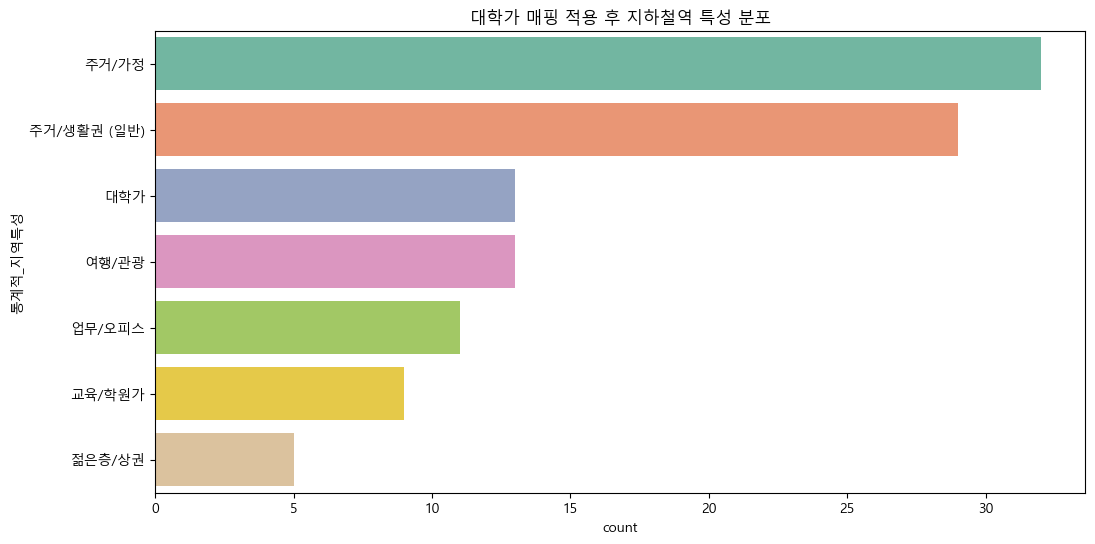


🎓 대학가로 분류된 역 목록 (13개):
['건대입구' '교대(법원.검찰청)' '동대입구' '서울대입구(관악구청)' '성신여대입구(돈암)' '숙대입구(갈월)' '신촌'
 '이대' '청량리(서울시립대입구)' '한성대입구(삼선교)' '한양대' '혜화' '홍대입구']


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# [Modified EDA] Z-Score 기반 역 특성 분류 + 대학가 별도 매핑
# ==============================================================================

# 1. [Manual Mapping] 대학가 역 리스트 정의 (사용자가 직접 추가/수정 가능)
# 1~4호선 주요 대학가 역들을 미리 정의합니다.
UNIVERSITY_STATIONS = [
    '홍대입구', '건대입구', '한양대', '이대', '신촌', '서울대입구', '교대', # 2호선
    '혜화', '성신여대입구', '한성대입구', '숙대입구', # 4호선
    '동대입구', # 3호선
    '회기', '외대앞', '석계' ,'청량리'# 1호선
]

def classify_station_zscore_final(df):
    target_cols = [
        'mart', 'store', 'kindergarten', 'school', 'academy', 'parking', 
        'gas_station', 'bank', 'culture', 'agency', 'public', 'attraction', 
        'accommodation', 'restaurant', 'cafe', 'hospital'
    ]
    
    # 2. 통계적 정규화 (Z-Score)
    df_z = df[target_cols].copy()
    for col in target_cols:
        mean = df_z[col].mean()
        std = df_z[col].std()
        if std == 0: df_z[col] = 0
        else: df_z[col] = (df_z[col] - mean) / std

    # 3. 특성별 점수 계산 (대학가 제외!)
    # 대학가 점수 계산 로직 삭제함
    
    # [A] 교육/학원가: 학원
    score_edu = df_z['academy'] * 3.0
    
    # [B] 젊은층/상권: 음식점 + 카페 + 문화
    score_youth = df_z['restaurant'] * 1.0 + df_z['cafe'] * 1.0 + df_z['culture'] * 0.5
    
    # [C] 여행/관광: 관광명소 + 숙박
    score_tour = df_z['attraction'] * 3.0 + df_z['accommodation'] * 2.0
    
    # [D] 업무/오피스: 은행 + 공공기관 + 중개업소
    score_biz = df_z['bank'] * 1.5 + df_z['public'] * 2.0 + df_z['agency'] * 1.0
    
    # [E] 주거/가정: 마트 + 유치원 + 병원 + 편의점
    score_res = df_z['mart'] * 2.0 + df_z['kindergarten'] * 2.0 + df_z['hospital'] * 1.5 + df_z['store'] * 1.0

    scores_df = pd.DataFrame({
        '교육/학원가': score_edu,
        '젊은층/상권': score_youth,
        '여행/관광': score_tour,
        '업무/오피스': score_biz,
        '주거/가정': score_res
    })
    
    # 4. 통계적 최대 점수 태깅
    def get_best_category(row):
        max_val = row.max()
        if max_val < 0.2: # 임계값 (특징 약함)
            return '주거/생활권 (일반)'
        return row.idxmax()

    # 우선 통계적으로 1차 분류 수행
    final_categories = scores_df.apply(get_best_category, axis=1)
    
    # 5. [Overwriting] 대학가 별도 매핑 적용
    # 역 이름이 UNIVERSITY_STATIONS 리스트에 있으면 강제로 '대학가'로 덮어씌움
    for idx, station_name in df['지하철역명'].items():
        # 역명에 괄호가 있을 수 있으므로 포함 여부로 확인하거나 전처리 필요
        # 여기서는 정확한 매칭 혹은 '홍대입구' in '홍대입구(경의선)' 같은 부분 일치 고려
        
        # 간단하게: 리스트에 있는 이름이 역명에 포함되면 대학가로 지정
        for univ_station in UNIVERSITY_STATIONS:
            if univ_station in station_name:
                final_categories[idx] = '대학가'
                break
                
    return final_categories

# 실행 및 결과 확인
if not df_infra.empty:
    df_result = df_infra.copy()
    # 수정된 함수 적용
    df_result['통계적_지역특성'] = classify_station_zscore_final(df_result)
    
    print("\n=== [최종 분류] 대학가 별도 매핑 + Z-Score 분류 결과 ===")
    
    # 1. 분포 확인
    count_data = df_result['통계적_지역특성'].value_counts()
    display(count_data)
    
    # 2. 시각화
    plt.figure(figsize=(12, 6))
    sns.countplot(y='통계적_지역특성', data=df_result, 
                  order=count_data.index, palette='Set2')
    plt.title("대학가 매핑 적용 후 지하철역 특성 분포")
    plt.show()
    
    # 3. 대학가로 잘 분류되었는지 검증
    univ_sample = df_result[df_result['통계적_지역특성'] == '대학가']['지하철역명'].values
    print(f"\n🎓 대학가로 분류된 역 목록 ({len(univ_sample)}개):")
    print(univ_sample)


=== 🌅 [출근 지옥철 TOP 5] (06~10시 승차 급증) ===
 -> 해석: 아침에 가장 타기 힘든 역 (주거 밀집 지역)


,지하철역명,급증_시간대,급증_인원수,분석_구간,유형
62,신림,07시_승차,110962.250000,06~10시,출근 승차 급증
61,신도림,07시_승차,84782.000000,06~10시,출근 승차 급증
8,구로디지털단지,07시_승차,84524.083333,06~10시,출근 승차 급증
48,서울대입구(관악구청),07시_승차,80429.416667,06~10시,출근 승차 급증
89,잠실(송파구청),07시_승차,69294.583333,06~10시,출근 승차 급증



=== 🌃 [퇴근/저녁 지옥철 TOP 5] (16~22시 승차 급증) ===
 -> 해석: 저녁에 가장 타기 힘든 역 (업무/상권 밀집 지역)


,지하철역명,급증_시간대,급증_인원수,분석_구간,유형
75,역삼,17시_승차,119714.333333,16~22시,퇴근 승차 급증
85,을지로입구,18시_승차,97986.250000,16~22시,퇴근 승차 급증
52,성수,18시_승차,95861.083333,16~22시,퇴근 승차 급증
45,삼성(무역센터),17시_승차,92716.083333,16~22시,퇴근 승차 급증
1,강남,17시_승차,85163.666667,16~22시,퇴근 승차 급증


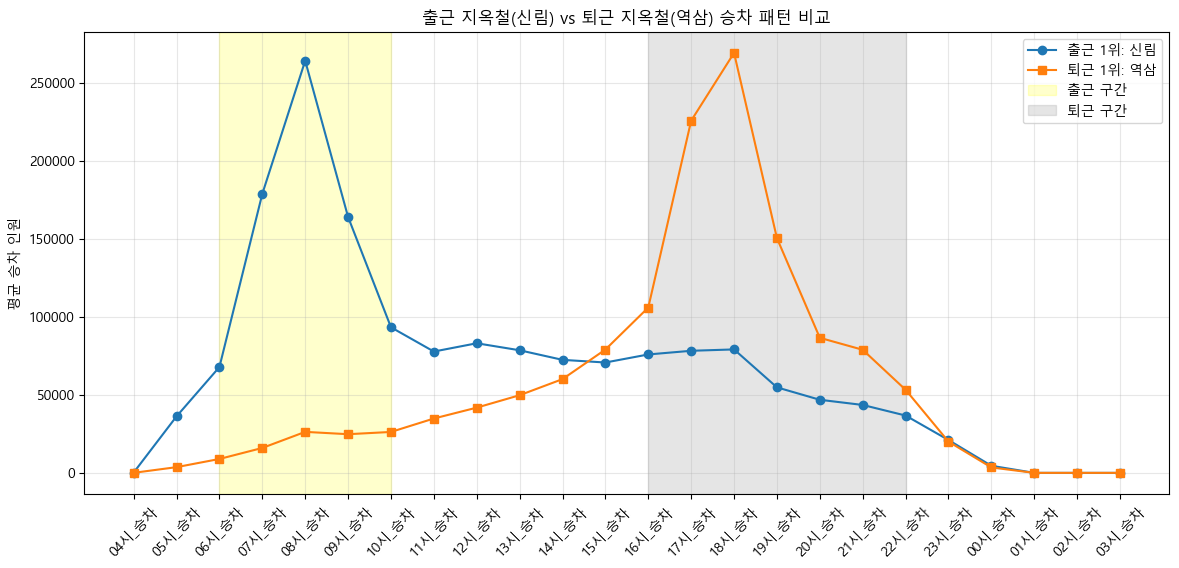

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================================================================
# 2. [Upgrade] 시간대별 급증(Surge) 구간 분리 탐지
# ==============================================================================

def find_surge_by_time_range(df, start_h, end_h, type_name="승차"):
    """
    특정 시간대(start_h ~ end_h) 사이의 급증 인원만 분석합니다.
    """
    # 1. 숫자 데이터 컬럼만 추출
    numeric_cols = [c for c in df.columns if '시' in c]
    
    # 2. 역별 평균 데이터 생성 (중복 제거)
    df_grouped = df.groupby('지하철역명')[numeric_cols].mean()
    
    # 3. 차분(Diff) 계산: (현재 시간 - 이전 시간)
    # 행: 시간, 열: 역
    df_diff = df_grouped.T.diff()
    
    # 4. [핵심] 요구하신 시간대로 인덱스 필터링
    # 인덱스 예시: "06시_승차", "22시_하차" 등
    filtered_indices = []
    for idx in df_diff.index:
        # "06시..." 에서 숫자만 추출
        try:
            hour = int(idx.split('시')[0])
            # 해당 시간 범위 내에 있는지 확인
            if start_h <= hour <= end_h:
                filtered_indices.append(idx)
        except:
            continue
            
    # 필터링된 시간대의 데이터만 남김
    df_diff_filtered = df_diff.loc[filtered_indices]
    
    # 5. 최대 급증량 찾기 (필터링된 구간 내에서)
    surge_list = []
    
    for station in df_diff_filtered.columns:
        # 필터링된 구간 내 최대값
        max_surge = df_diff_filtered[station].max()
        
        if pd.isna(max_surge): continue
        
        # 최대 급증 시간대
        max_time_idx = df_diff_filtered[station].idxmax()
        
        surge_list.append({
            '지하철역명': station,
            '급증_시간대': max_time_idx,
            '급증_인원수': max_surge,
            '분석_구간': f"{start_h:02d}~{end_h:02d}시",
            '유형': type_name
        })
        
    return pd.DataFrame(surge_list).sort_values('급증_인원수', ascending=False)


# --- 실행 및 결과 확인 ---
if not df_boarding.empty and not df_alighting.empty:
    
    # [Case 1] 출근 지옥철 (06시 ~ 10시 승차 급증)
    # 주거지에서 사람들이 쏟아져 나오는 곳
    morning_surge = find_surge_by_time_range(df_boarding, 6, 10, "출근 승차 급증")
    
    # [Case 2] 저녁/퇴근 지옥철 (16시 ~ 22시 승차 급증)
    # 업무지구/상권에서 집으로 가려고 타는 곳
    evening_surge = find_surge_by_time_range(df_boarding, 16, 22, "퇴근 승차 급증")

    print("\n=== 🌅 [출근 지옥철 TOP 5] (06~10시 승차 급증) ===")
    print(" -> 해석: 아침에 가장 타기 힘든 역 (주거 밀집 지역)")
    display(morning_surge.head(5))
    
    print("\n=== 🌃 [퇴근/저녁 지옥철 TOP 5] (16~22시 승차 급증) ===")
    print(" -> 해석: 저녁에 가장 타기 힘든 역 (업무/상권 밀집 지역)")
    display(evening_surge.head(5))

    # --- 시각화: 출근 1위 vs 퇴근 1위 비교 ---
    plt.figure(figsize=(14, 6))
    
    # 출근 1위 역
    top_morning = morning_surge.iloc[0]['지하철역명']
    # 퇴근 1위 역
    top_evening = evening_surge.iloc[0]['지하철역명']
    
    # 전체 시간대 가져오기 (그래프용)
    all_time_cols = [c for c in df_boarding.columns if '시_승차' in c]
    
    # 데이터 추출 (평균)
    val_morning = df_boarding[df_boarding['지하철역명'] == top_morning][all_time_cols].mean(axis=0).values
    val_evening = df_boarding[df_boarding['지하철역명'] == top_evening][all_time_cols].mean(axis=0).values
    
    plt.plot(all_time_cols, val_morning, marker='o', label=f'출근 1위: {top_morning}')
    plt.plot(all_time_cols, val_evening, marker='s', label=f'퇴근 1위: {top_evening}')
    
    # 구간 표시
    plt.axvspan('06시_승차', '10시_승차', color='yellow', alpha=0.2, label='출근 구간')
    plt.axvspan('16시_승차', '22시_승차', color='gray', alpha=0.2, label='퇴근 구간')
    
    plt.title(f"출근 지옥철({top_morning}) vs 퇴근 지옥철({top_evening}) 승차 패턴 비교")
    plt.xticks(rotation=45)
    plt.ylabel("평균 승차 인원")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


=== 🏢 [Morning Destination] 아침(07~10시) 하차 인원 TOP 10 ===
 -> 해석: 대한민국의 주요 일자리/학교가 몰려있는 곳


,아침(07-10)_평균하차수
지하철역명,
강남,945542.166667
역삼,932034.166667
삼성(무역센터),825656.166667
선릉,720880.500000
을지로입구,715813.666667
성수,592465.333333
종각,583012.333333
잠실(송파구청),549650.083333
양재(서초구청),506834.500000



=== 🏠 [Evening Destination] 저녁(18~22시) 하차 인원 TOP 10 ===
 -> 해석: 사람들이 사는 곳(주거지) 혹은 저녁 약속 장소


,저녁(18-22)_평균하차수
지하철역명,
신림,771749.000000
잠실(송파구청),692853.500000
홍대입구,687056.250000
서울대입구(관악구청),555609.500000
구로디지털단지,541965.083333
신도림,506614.500000
건대입구,439842.333333
강남,439207.500000
수유(강북구청),422608.833333


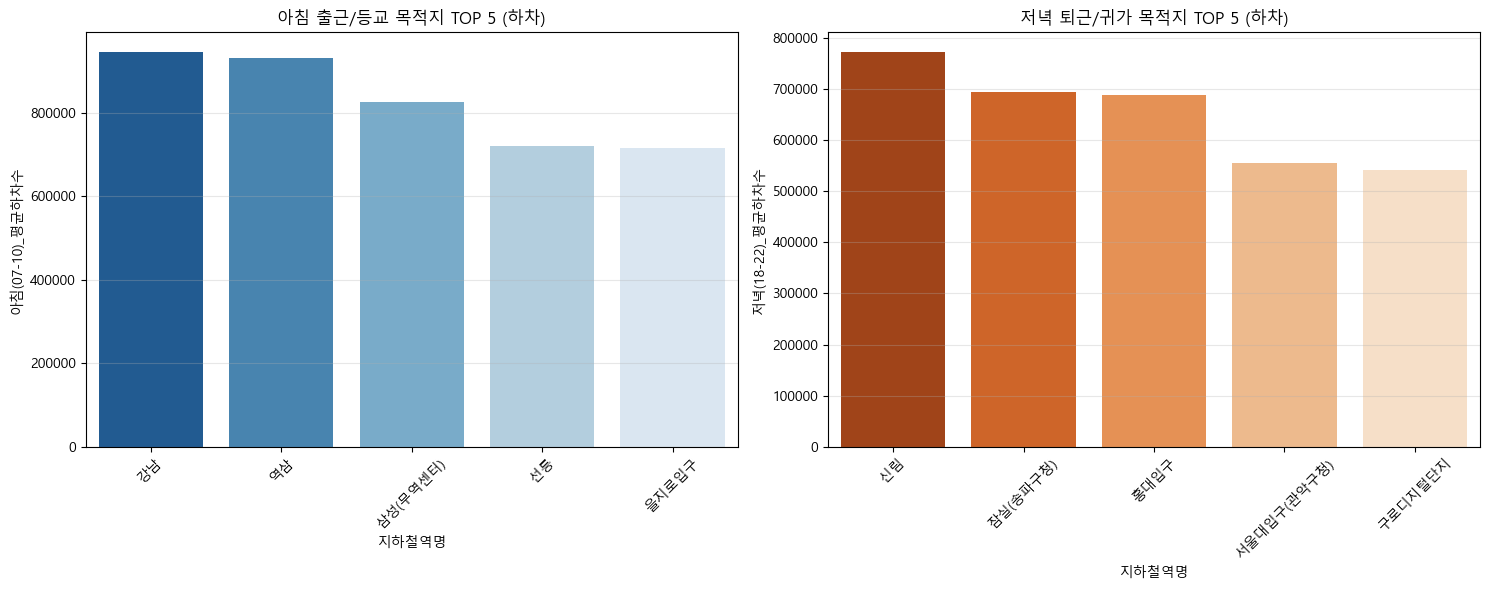

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# 3. [Reverse Analysis] 아침/저녁 하차 폭탄 구간(Destination) 분석
# ==============================================================================

def get_top_alighting_volume(df, start_h, end_h, label_name):
    """
    특정 시간대(start_h ~ end_h)에 하차 인원 합계(Volume)가 가장 많은 역을 찾습니다.
    """
    # 1. 대상 시간대 컬럼 찾기 ("07시_하차", "08시_하차" ...)
    target_cols = []
    for c in df.columns:
        if '시_하차' in c:
            try:
                hour = int(c.split('시')[0])
                if start_h <= hour <= end_h:
                    target_cols.append(c)
            except:
                continue
    
    # 2. 역별로 그룹화하여 '평균' 데이터 생성 (1년치 데이터 압축)
    # 각 역의 '평소 하루' 하차량을 계산
    df_avg = df.groupby('지하철역명')[target_cols].mean()
    
    # 3. 해당 시간대의 총 하차 인원 합계 계산 (Volume)
    # axis=1 (가로 방향 합계)
    df_avg['Total_Volume'] = df_avg.sum(axis=1)
    
    # 4. 내림차순 정렬 및 Top 10 추출
    top_stations = df_avg.sort_values('Total_Volume', ascending=False).head(10)
    
    # 결과 포맷팅
    result_df = top_stations[['Total_Volume']].copy()
    result_df.columns = [f'{label_name}_평균하차수']
    
    return result_df

# --- 실행 및 시각화 ---
if not df_alighting.empty:
    
    # [Case 1] 아침 하차 집중 (07시 ~ 10시) -> "여기로 출근/등교한다"
    # 대표적인 업무지구(Office District) 또는 대학가
    top_morning_dest = get_top_alighting_volume(df_alighting, 7, 10, "아침(07-10)")
    
    # [Case 2] 저녁 하차 집중 (18시 ~ 22시) -> "여기로 퇴근/귀가한다"
    # 대표적인 주거지(Bed Town) 또는 저녁 약속 장소(Nightlife)
    top_evening_dest = get_top_alighting_volume(df_alighting, 18, 22, "저녁(18-22)")

    print("\n=== 🏢 [Morning Destination] 아침(07~10시) 하차 인원 TOP 10 ===")
    print(" -> 해석: 대한민국의 주요 일자리/학교가 몰려있는 곳")
    display(top_morning_dest)
    
    print("\n=== 🏠 [Evening Destination] 저녁(18~22시) 하차 인원 TOP 10 ===")
    print(" -> 해석: 사람들이 사는 곳(주거지) 혹은 저녁 약속 장소")
    display(top_evening_dest)

   # --- 시각화: 출근지 vs 퇴근지 TOP 5 비교 (수정됨) ---
    plt.figure(figsize=(15, 6))
    
    # [수정 1] 아침 하차 Top 5
    plt.subplot(1, 2, 1)
    # 데이터를 변수에 담아서 명확하게 전달
    plot_data_morning = top_morning_dest.head(5)
    
    sns.barplot(
        x=plot_data_morning.index, 
        y='아침(07-10)_평균하차수', 
        data=plot_data_morning,  # <--- [중요] data 파라미터 추가!
        palette='Blues_r',
        hue=plot_data_morning.index, # (경고 방지용) hue에 x와 같은 값 지정
        legend=False # (범례 중복 방지)
    )
    plt.title("아침 출근/등교 목적지 TOP 5 (하차)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # [수정 2] 저녁 하차 Top 5
    plt.subplot(1, 2, 2)
    plot_data_evening = top_evening_dest.head(5)
    
    sns.barplot(
        x=plot_data_evening.index, 
        y='저녁(18-22)_평균하차수', 
        data=plot_data_evening,  # <--- [중요] data 파라미터 추가!
        palette='Oranges_r',
        hue=plot_data_evening.index, # (경고 방지용)
        legend=False
    )
    plt.title("저녁 퇴근/귀가 목적지 TOP 5 (하차)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


🏢 [검증 A] 아침(07-09시) 하차 인원 TOP 20 역의 지역 특성


,지하철역명,총이동인원,통계적_지역특성,랜드마크
75,역삼,811056.500000,업무/오피스,
1,강남,788413.166667,교육/학원가,
45,삼성(무역센터),702023.333333,업무/오피스,무역센터
85,을지로입구,624780.083333,업무/오피스,
51,선릉,618366.833333,교육/학원가,
94,종각,521106.000000,업무/오피스,
52,성수,486265.500000,젊은층/상권,
73,양재(서초구청),451152.250000,업무/오피스,서초구청
8,구로디지털단지,434847.000000,여행/관광,
89,잠실(송파구청),419926.833333,주거/가정,송파구청



🏠 [검증 B] 아침(07-09시) 승차 인원 TOP 20 역의 지역 특성


,지하철역명,총이동인원,통계적_지역특성,랜드마크
62,신림,606781.083333,업무/오피스,
8,구로디지털단지,432154.583333,여행/관광,
48,서울대입구(관악구청),416010.083333,대학가,관악구청
89,잠실(송파구청),404446.416667,주거/가정,송파구청
61,신도림,380982.833333,주거/가정,
76,연신내,341500.416667,주거/가정,
68,쌍문,322858.916667,주거/생활권 (일반),
55,수유(강북구청),306663.333333,업무/오피스,강북구청
60,신대방,298320.000000,주거/생활권 (일반),
13,낙성대(강감찬),286664.666667,주거/가정,강감찬


C:\Users\USER\AppData\Local\Temp\ipykernel_2160\2716116595.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='통계적_지역특성', data=top_morning_dest, palette='coolwarm',
C:\Users\USER\AppData\Local\Temp\ipykernel_2160\2716116595.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='통계적_지역특성', data=top_morning_origin, palette='viridis',


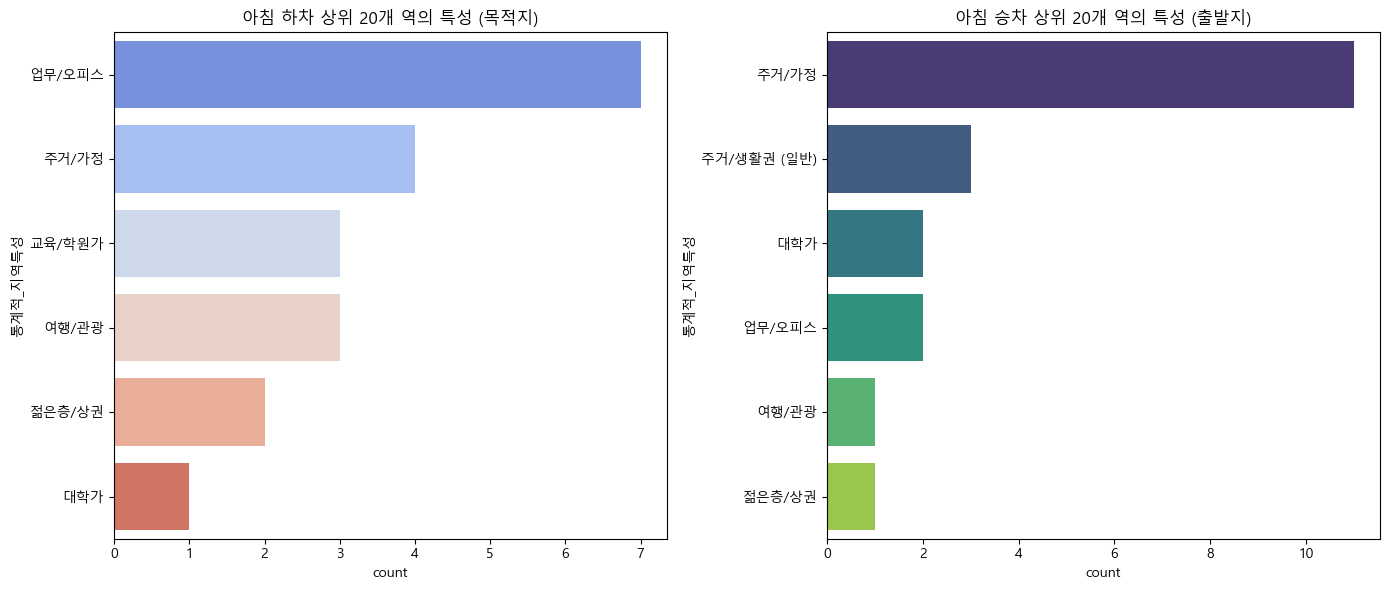

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# 4. [Hypothesis Verification] 승하차 Top 역의 지역 특성 매핑
# ==============================================================================

def analyze_top_stations_characteristics(df_ridership, df_infra, start_h, end_h, type_name="하차"):
    """
    특정 시간대 승/하차 인원 상위 역을 뽑고, 그 역의 지역 특성(인프라)을 붙여서 보여줍니다.
    """
    # 1. 대상 시간대 컬럼 추출
    target_cols = []
    keyword = "승차" if type_name == "승차" else "하차"
    
    for c in df_ridership.columns:
        if keyword in c:
            try:
                hour = int(c.split('시')[0])
                if start_h <= hour <= end_h:
                    target_cols.append(c)
            except:
                continue
                
    # 2. 역별 해당 시간대 총 인원 계산
    # (이미 역별로 groupby된 데이터라면 바로 sum, 아니라면 groupby 후 sum)
    if '지하철역명' in df_ridership.columns:
        # 원본 데이터인 경우 그룹화
        df_vol = df_ridership.groupby('지하철역명')[target_cols].mean().sum(axis=1).reset_index()
    else:
        # 이미 인덱스가 역명인 경우
        df_vol = df_ridership[target_cols].sum(axis=1).reset_index()
        
    df_vol.columns = ['지하철역명', '총이동인원']
    
    # 3. 인프라 특성 데이터(df_infra 혹은 df_result)와 결합
    # df_result에 '통계적_지역특성' 컬럼이 있어야 함
    if '통계적_지역특성' in df_infra.columns:
        merged_df = pd.merge(df_vol, df_infra[['지하철역명', '통계적_지역특성', '랜드마크', '환승역']], 
                             on='지하철역명', how='left')
    else:
        print("⚠️ 주의: 인프라 데이터에 '통계적_지역특성' 컬럼이 없습니다. 이전 Z-Score 코드를 실행해주세요.")
        return None

    # 4. 상위 20개 추출
    top_20 = merged_df.sort_values('총이동인원', ascending=False).head(20)
    return top_20

# --- 실행 및 결과 확인 ---
# df_result: Z-Score로 분류된 데이터프레임 (이전 단계 결과물)
# df_alighting: 하차 데이터
# df_boarding: 승차 데이터

if 'df_result' in locals() and not df_alighting.empty:
    
    # [Scenario A] 아침(07-09시) 출근 시간대 하차 TOP 20 -> "직장인/학생들의 목적지"
    print("\n🏢 [검증 A] 아침(07-09시) 하차 인원 TOP 20 역의 지역 특성")
    top_morning_dest = analyze_top_stations_characteristics(df_alighting, df_result, 7, 9, "하차")
    
    display(top_morning_dest[['지하철역명', '총이동인원', '통계적_지역특성', '랜드마크']])
    
    # [Scenario B] 아침(07-09시) 출근 시간대 승차 TOP 20 -> "주거 밀집 지역"
    print("\n🏠 [검증 B] 아침(07-09시) 승차 인원 TOP 20 역의 지역 특성")
    top_morning_origin = analyze_top_stations_characteristics(df_boarding, df_result, 7, 9, "승차")
    
    display(top_morning_origin[['지하철역명', '총이동인원', '통계적_지역특성', '랜드마크']])

    # --- 시각화: 상위권 역들의 특성 분포 비교 ---
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.countplot(y='통계적_지역특성', data=top_morning_dest, palette='coolwarm', 
                  order=top_morning_dest['통계적_지역특성'].value_counts().index)
    plt.title("아침 하차 상위 20개 역의 특성 (목적지)")
    
    plt.subplot(1, 2, 2)
    sns.countplot(y='통계적_지역특성', data=top_morning_origin, palette='viridis',
                  order=top_morning_origin['통계적_지역특성'].value_counts().index)
    plt.title("아침 승차 상위 20개 역의 특성 (출발지)")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ 필요한 데이터프레임(df_result, df_alighting)이 로드되지 않았습니다.")


🏠 [검증 C] 저녁(18-22시) 하차 인원 TOP 20 역의 지역 특성


,지하철역명,총이동인원,통계적_지역특성,랜드마크
62,신림,771749.000000,업무/오피스,
89,잠실(송파구청),692853.500000,주거/가정,송파구청
109,홍대입구,687056.250000,대학가,
48,서울대입구(관악구청),555609.500000,대학가,관악구청
8,구로디지털단지,541965.083333,여행/관광,
61,신도림,506614.500000,주거/가정,
3,건대입구,439842.333333,대학가,
1,강남,439207.500000,교육/학원가,
55,수유(강북구청),422608.833333,업무/오피스,강북구청
76,연신내,415955.666667,주거/가정,



🏢 [검증 D] 저녁(18-22시) 승차 인원 TOP 20 역의 지역 특성


,지하철역명,총이동인원,통계적_지역특성,랜드마크
1,강남,1.038824e+06,교육/학원가,
109,홍대입구,9.708856e+05,대학가,
89,잠실(송파구청),8.529639e+05,주거/가정,송파구청
45,삼성(무역센터),7.329852e+05,업무/오피스,무역센터
52,성수,7.204323e+05,젊은층/상권,
85,을지로입구,7.113962e+05,업무/오피스,
51,선릉,6.873693e+05,교육/학원가,
75,역삼,6.380932e+05,업무/오피스,
94,종각,5.531677e+05,업무/오피스,
6,고속터미널,5.328230e+05,교육/학원가,


C:\Users\USER\AppData\Local\Temp\ipykernel_2160\1683084503.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(y='통계적_지역특성', data=top_evening_dest, palette='Oranges_r',
C:\Users\USER\AppData\Local\Temp\ipykernel_2160\1683084503.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(y='통계적_지역특성', data=top_evening_origin, palette='Purples_r',


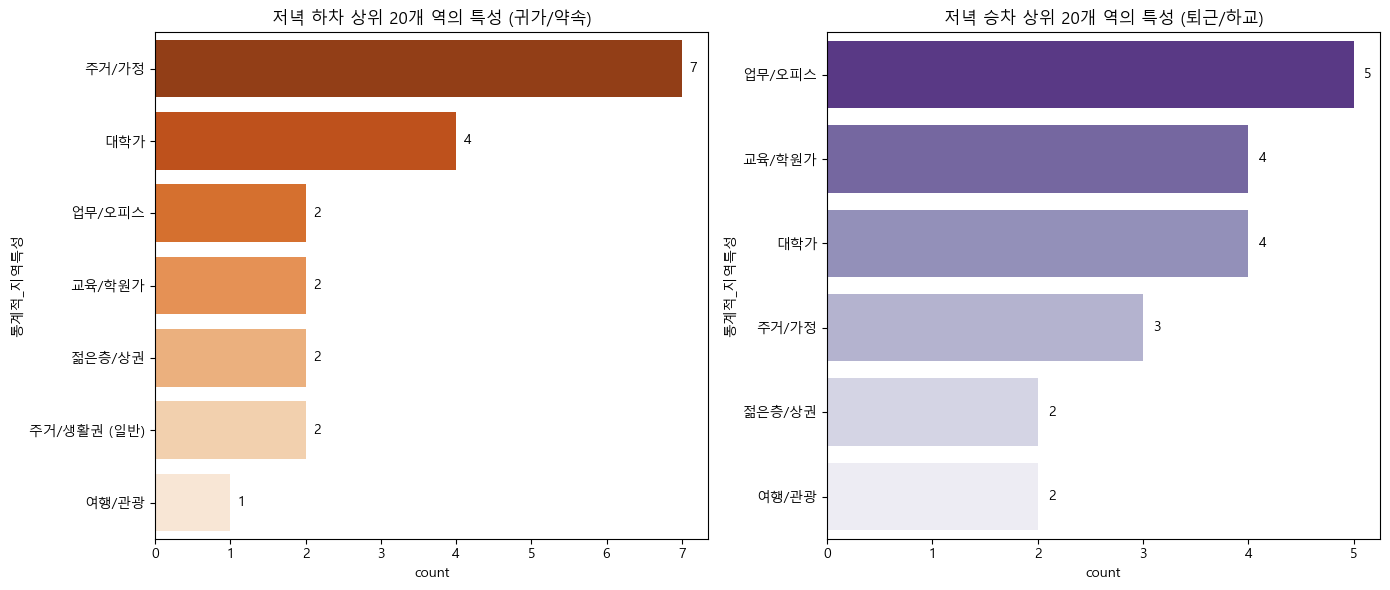

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# (analyze_top_stations_characteristics 함수는 이미 정의되어 있다고 가정합니다)

if 'df_result' in locals() and not df_alighting.empty and not df_boarding.empty:
    
    # --------------------------------------------------------------------------
    # [Scenario C] 저녁(18-22시) 하차 TOP 20 -> "귀가(주거지) 또는 저녁약속(번화가)"
    # --------------------------------------------------------------------------
    print("\n🏠 [검증 C] 저녁(18-22시) 하차 인원 TOP 20 역의 지역 특성")
    # 하차 = 목적지 (집 또는 식당)
    top_evening_dest = analyze_top_stations_characteristics(df_alighting, df_result, 18, 22, "하차")
    
    display(top_evening_dest[['지하철역명', '총이동인원', '통계적_지역특성', '랜드마크']])
    
    
    # --------------------------------------------------------------------------
    # [Scenario D] 저녁(18-22시) 승차 TOP 20 -> "퇴근(업무지구)"
    # --------------------------------------------------------------------------
    print("\n🏢 [검증 D] 저녁(18-22시) 승차 인원 TOP 20 역의 지역 특성")
    # 승차 = 출발지 (회사)
    top_evening_origin = analyze_top_stations_characteristics(df_boarding, df_result, 18, 22, "승차")
    
    display(top_evening_origin[['지하철역명', '총이동인원', '통계적_지역특성', '랜드마크']])


    # --------------------------------------------------------------------------
    # 시각화: 저녁 시간대 특성 분포 비교
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    
    # 그래프 1: 저녁 하차 (목적지)
    plt.subplot(1, 2, 1)
    ax1 = sns.countplot(y='통계적_지역특성', data=top_evening_dest, palette='Oranges_r', 
                        order=top_evening_dest['통계적_지역특성'].value_counts().index)
    plt.title("저녁 하차 상위 20개 역의 특성 (귀가/약속)")
    
    # 막대 끝에 숫자 표시
    for p in ax1.patches:
        ax1.text(p.get_width() + 0.1, p.get_y() + p.get_height()/2, 
                 f'{int(p.get_width())}', va='center')
    
    # 그래프 2: 저녁 승차 (출발지)
    plt.subplot(1, 2, 2)
    ax2 = sns.countplot(y='통계적_지역특성', data=top_evening_origin, palette='Purples_r',
                        order=top_evening_origin['통계적_지역특성'].value_counts().index)
    plt.title("저녁 승차 상위 20개 역의 특성 (퇴근/하교)")
    
    # 막대 끝에 숫자 표시
    for p in ax2.patches:
        ax2.text(p.get_width() + 0.1, p.get_y() + p.get_height()/2, 
                 f'{int(p.get_width())}', va='center')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 데이터가 로드되지 않았습니다. 이전 단계 코드를 먼저 실행해주세요.")

In [3]:
import pandas as pd
import numpy as np
import json
import os

# -----------------------------------------------------------------------------
# 1. 데이터 로드
# -----------------------------------------------------------------------------
seoul_path = "../data/raw/seoul_ridership_202411_202510_1to4.json"
kakao_path = "../data/raw/kakao_station_poi_1to4_full.json"

try:
    with open(seoul_path, 'r', encoding='utf-8') as f:
        seoul_data = json.load(f)
    with open(kakao_path, 'r', encoding='utf-8') as f:
        kakao_data = json.load(f)
    print("✅ 데이터 로드 성공")
except FileNotFoundError:
    print("❌ 경로 오류: ../data/raw/ 폴더에 파일이 있는지 확인해주세요.")
    seoul_data = []
    kakao_data = []

# DataFrame 변환
df_seoul = pd.DataFrame(seoul_data)
df_kakao = pd.DataFrame(kakao_data)

# -----------------------------------------------------------------------------
# 2. 승하차 데이터 전처리 (df_boarding, df_alighting 생성)
# -----------------------------------------------------------------------------
# 시간대 정렬 (04시 ~ 03시)
time_order = list(range(4, 24)) + [0, 1, 2, 3]
on_cols_ordered = [f"HR_{t}_GET_ON_NOPE" for t in time_order]
off_cols_ordered = [f"HR_{t}_GET_OFF_NOPE" for t in time_order]

# 승차 테이블 생성
valid_on_cols = [c for c in on_cols_ordered if c in df_seoul.columns]
df_boarding = df_seoul[['STTN', 'USE_MM'] + valid_on_cols].copy()
df_boarding.rename(columns={'STTN': '지하철역명', 'USE_MM': '사용월'}, inplace=True)
rename_map_on = {col: f"{int(col.split('_')[1]):02d}시_승차" for col in valid_on_cols}
df_boarding.rename(columns=rename_map_on, inplace=True)

# 하차 테이블 생성
valid_off_cols = [c for c in off_cols_ordered if c in df_seoul.columns]
df_alighting = df_seoul[['STTN', 'USE_MM'] + valid_off_cols].copy()
df_alighting.rename(columns={'STTN': '지하철역명', 'USE_MM': '사용월'}, inplace=True)
rename_map_off = {col: f"{int(col.split('_')[1]):02d}시_하차" for col in valid_off_cols}
df_alighting.rename(columns=rename_map_off, inplace=True)

# -----------------------------------------------------------------------------
# 3. 인프라 데이터 전처리 및 특성 분류 (df_infra 생성)
# -----------------------------------------------------------------------------
# POI 펼치기
poi_df = pd.json_normalize(df_kakao['poi_counts']).fillna(0)
df_infra = pd.concat([df_kakao[['station_name', 'line_filters']], poi_df], axis=1)
df_infra.rename(columns={'station_name': '지하철역명', 'line_filters': '환승역'}, inplace=True)
df_infra['랜드마크'] = df_infra['지하철역명'].str.extract(r'\((.*?)\)')[0].fillna('')

# --- [분류 로직] Z-Score 기반 지역 특성 태깅 ---
def classify_station_final(df):
    target_cols = [c for c in df.columns if c in ['mart', 'store', 'school', 'academy', 'bank', 'culture', 'public', 'attraction', 'accommodation', 'restaurant', 'cafe', 'hospital', 'kindergarten', 'agency']]
    
    # Z-Score 변환
    df_z = df[target_cols].copy()
    for col in target_cols:
        if df_z[col].std() != 0:
            df_z[col] = (df_z[col] - df_z[col].mean()) / df_z[col].std()
        else:
            df_z[col] = 0

    # 점수 계산
    score_edu = df_z.get('academy', 0) * 3.0
    score_youth = df_z.get('restaurant', 0) * 1.0 + df_z.get('cafe', 0) * 1.0 + df_z.get('culture', 0) * 0.5
    score_tour = df_z.get('attraction', 0) * 3.0 + df_z.get('accommodation', 0) * 2.0
    score_biz = df_z.get('bank', 0) * 1.5 + df_z.get('public', 0) * 2.0 + df_z.get('agency', 0) * 1.0
    score_res = df_z.get('mart', 0) * 2.0 + df_z.get('kindergarten', 0) * 2.0 + df_z.get('hospital', 0) * 1.5 + df_z.get('store', 0) * 1.0

    scores = pd.DataFrame({'교육/학원가': score_edu, '젊은층/상권': score_youth, '여행/관광': score_tour, '업무/오피스': score_biz, '주거/가정': score_res})
    
    def get_cat(row):
        return row.idxmax() if row.max() >= 0.2 else '주거/생활권 (일반)'
    
    cats = scores.apply(get_cat, axis=1)
    
    # 대학가 별도 매핑
    univ_stations = ['홍대입구', '건대입구', '한양대', '이대', '신촌', '서울대입구', '교대', '혜화', '성신여대', '한성대', '숙대', '회기', '외대', '석계']
    for idx, name in df['지하철역명'].items():
        if any(u in name for u in univ_stations):
            cats[idx] = '대학가'
            
    return cats

if not df_infra.empty:
    df_infra['통계적_지역특성'] = classify_station_final(df_infra)

# -----------------------------------------------------------------------------
# 4. 최종 데이터 병합 및 저장 (CSV)
# -----------------------------------------------------------------------------
# 승하차 데이터 평균치 (역명 기준)
avg_board = df_boarding.groupby('지하철역명').mean(numeric_only=True)
avg_alight = df_alighting.groupby('지하철역명').mean(numeric_only=True)

# 인프라 + 승차 + 하차 결합
final_df = pd.merge(df_infra, avg_board, on='지하철역명', how='left')
final_df = pd.merge(final_df, avg_alight, on='지하철역명', how='left')

# 호선 정보 (가장 처음 발견된 호선)
line_info = df_seoul[['STTN', 'SBWY_ROUT_LN_NM']].drop_duplicates('STTN').rename(columns={'STTN':'지하철역명'})
final_df = pd.merge(final_df, line_info, on='지하철역명', how='left')

# 저장 폴더 확인
os.makedirs("../data/processed", exist_ok=True)
save_path = "../data/processed/subway_final_data.csv"

final_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"✅ 최종 데이터 저장 완료: {save_path}")
print(f"   - 데이터 크기: {final_df.shape}")
print("   - 이제 app.py를 실행하시면 됩니다!")

✅ 데이터 로드 성공
✅ 최종 데이터 저장 완료: ../data/processed/subway_final_data.csv
   - 데이터 크기: (112, 71)
   - 이제 app.py를 실행하시면 됩니다!
